In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

In [2]:
def count_edges(G):
    return sum(len(neighbors) for neighbors in G.adj.values()) // 2

def calculate_edge_density(edge_count, vertex_count):
    """Calculate edge density of a graph."""
    max_possible_edges = (vertex_count * (vertex_count - 1)) / 2
    return edge_count / max_possible_edges

def is_bipartite(G):
    color = {}
    for start_node in G.nodes():
        if start_node not in color:
            stack = [(start_node, 0)]
            while stack:
                node, c = stack.pop()
                if node in color:
                    if color[node] != c:
                        return False
                else:
                    color[node] = c
                    stack.extend((neighbor, 1 - c) for neighbor in G.adj[node])
    return True

def find_diameter(G):
    if not nx.is_connected(G):
        return float('inf')
    def bfs(start):
        distances = {start: 0}
        queue = [start]
        while queue:
            node = queue.pop(0)
            for neighbor in G.adj[node]:
                if neighbor not in distances:
                    distances[neighbor] = distances[node] + 1
                    queue.append(neighbor)
        return max(distances.values())
    
    return max(bfs(node) for node in G.nodes())

def find_max_clique(G):
    def is_clique(nodes):
        return all(v in G.adj[u] for u in nodes for v in nodes if u != v)

    def backtrack(candidates, clique):
        if not candidates:
            return clique
        v = max(candidates, key=lambda x: len(G.adj[x]))
        candidates.remove(v)
        new_clique = clique | {v}
        for u in list(candidates):
            if not all(u in G.adj[w] for w in new_clique):
                candidates.remove(u)
        return max((backtrack(candidates.copy(), new_clique), clique), key=len)

    return len(backtrack(set(G.nodes()), set()))

def average_clustering(G):
    def local_clustering(node):
        neighbors = list(G.adj[node])
        if len(neighbors) < 2:
            return 0
        links = sum(1 for u in neighbors for v in neighbors if u < v and v in G.adj[u])
        possible_links = len(neighbors) * (len(neighbors) - 1) / 2
        return links / possible_links if possible_links > 0 else 0
    
    if len(G.nodes()) == 0:
        return 0
    return sum(local_clustering(node) for node in G.nodes()) / len(G.nodes())

def estimate_group_size(G):
    degree_counts = defaultdict(int)
    for node in G.nodes():
        degree_counts[len(G.adj[node])] += 1
    return max(degree_counts.values()) if degree_counts else 0

def estimate_orbit_count(G):
    return len(set(len(G.adj[node]) for node in G.nodes()))

def collect_graph_properties(filename, n_vertices):
    properties = {
        'edge_counts': [],
        'edge_densities': [],
        'bipartite_counts': defaultdict(int),
        'diameters': [],
        'clique_numbers': [],
        'max_degrees': [],
        'clustering_coefficients': [],
        'group_sizes': [],
        'orbit_counts': []
    }
    
    with open(filename, 'r') as file:
        for line in file:
            try:
                G = nx.from_graph6_bytes(line.strip().encode('utf-8'))
                edge_count = count_edges(G)

                properties['edge_counts'].append(edge_count)
                properties['edge_densities'].append(calculate_edge_density(edge_count, n_vertices))
                properties['bipartite_counts'][is_bipartite(G)] += 1
                
                if nx.is_connected(G):
                    properties['diameters'].append(find_diameter(G))
                
                properties['clique_numbers'].append(find_max_clique(G))
                properties['max_degrees'].append(max(G.degree(node) for node in G.nodes()))
                properties['clustering_coefficients'].append(average_clustering(G))
                properties['group_sizes'].append(estimate_group_size(G))
                properties['orbit_counts'].append(estimate_orbit_count(G))

            except nx.NetworkXError as e:
                print(f"Error processing graph: {e}")
    
    return properties

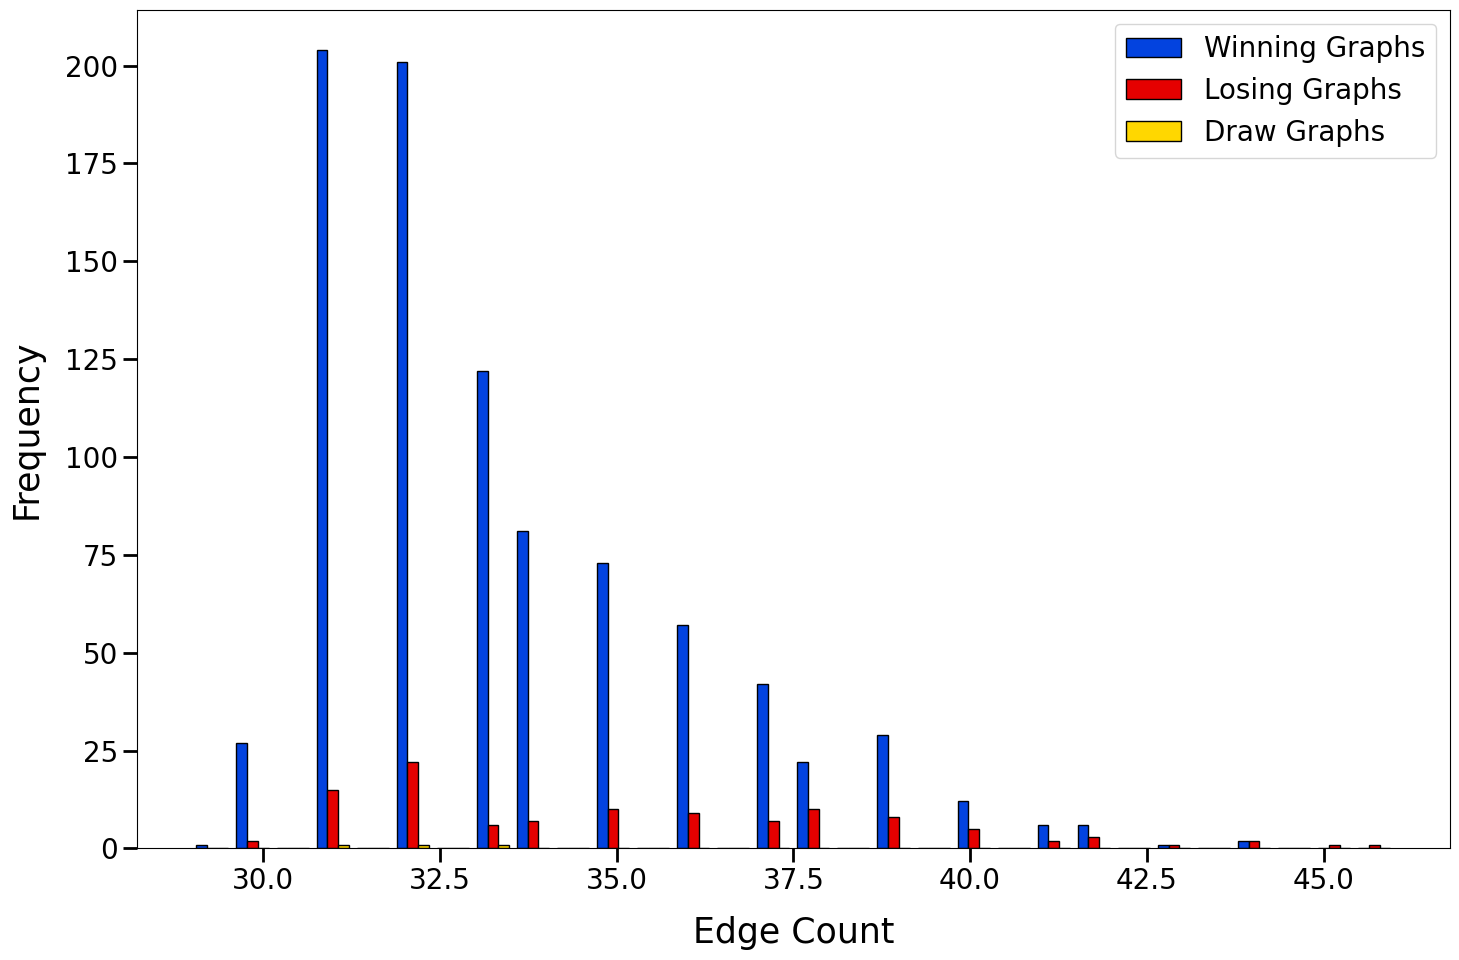

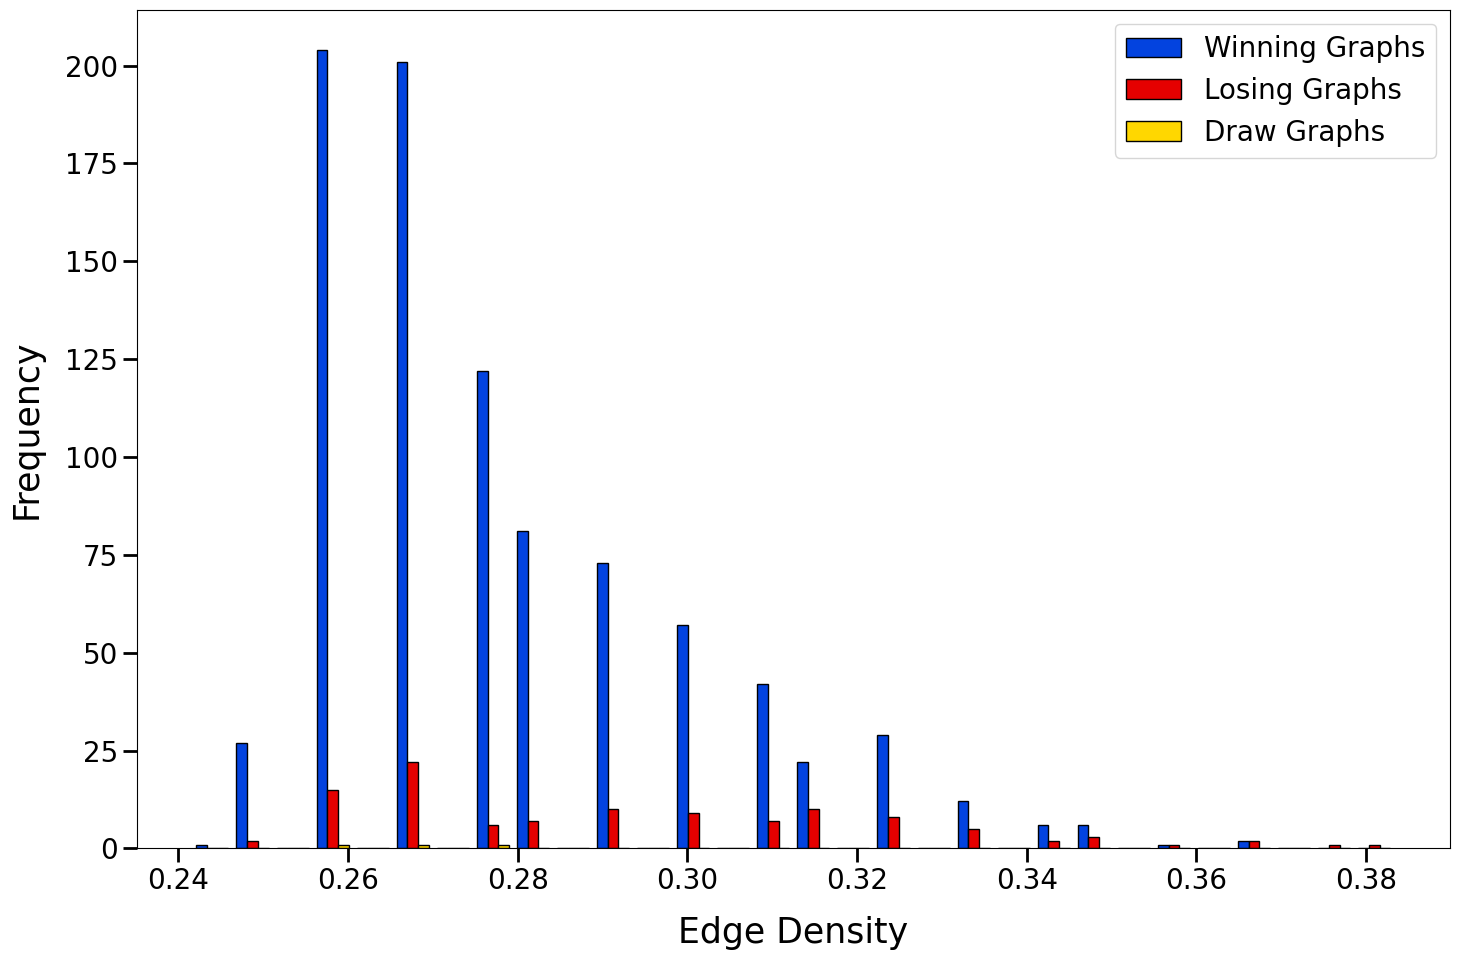

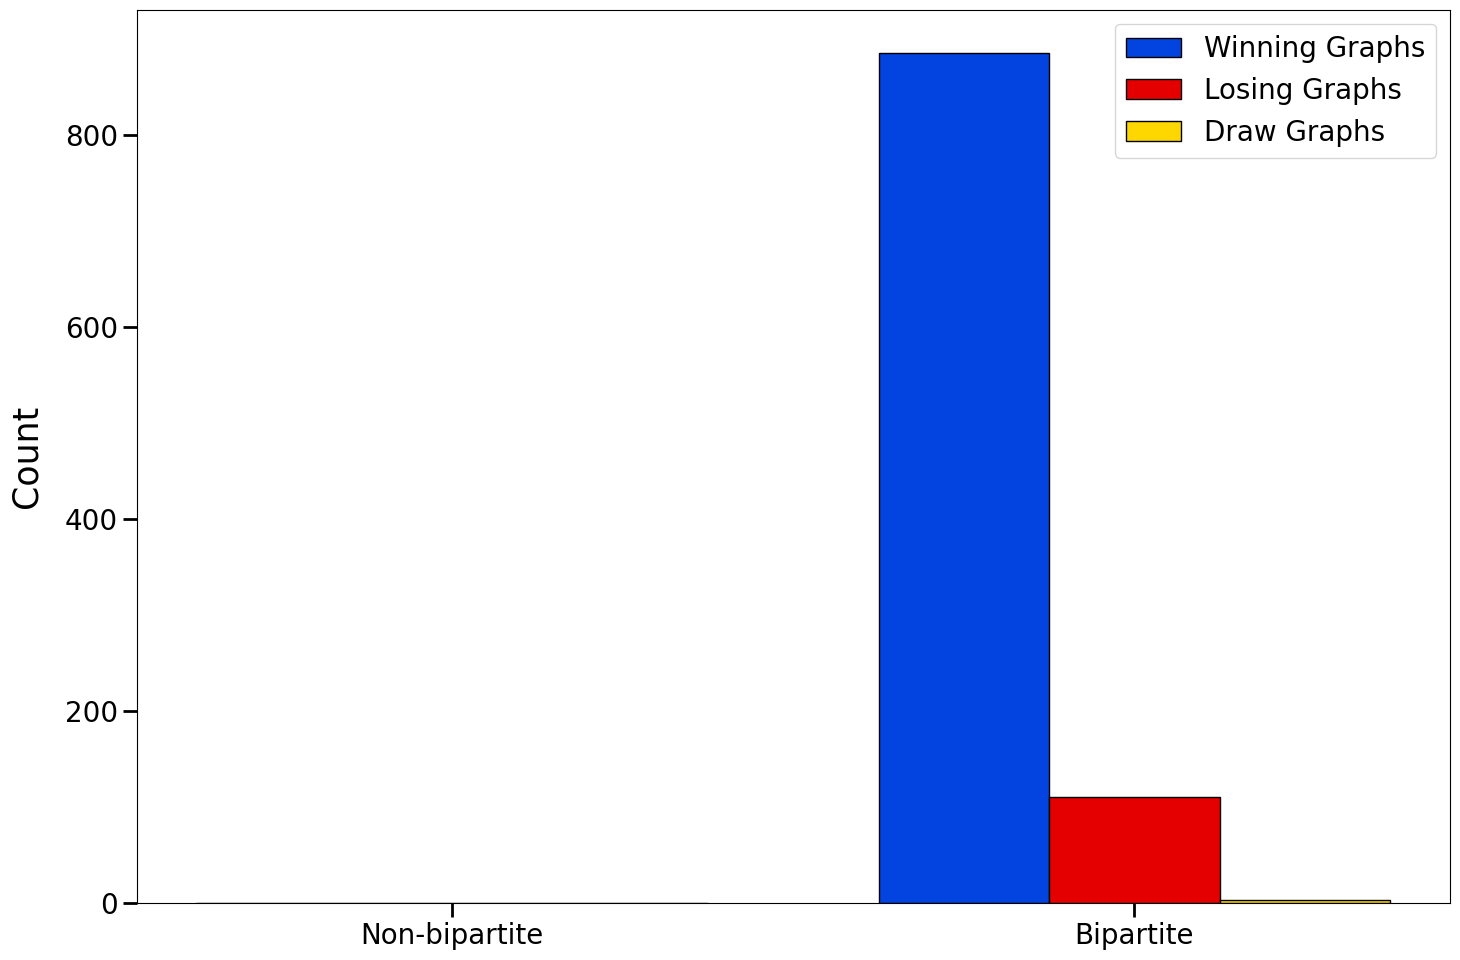

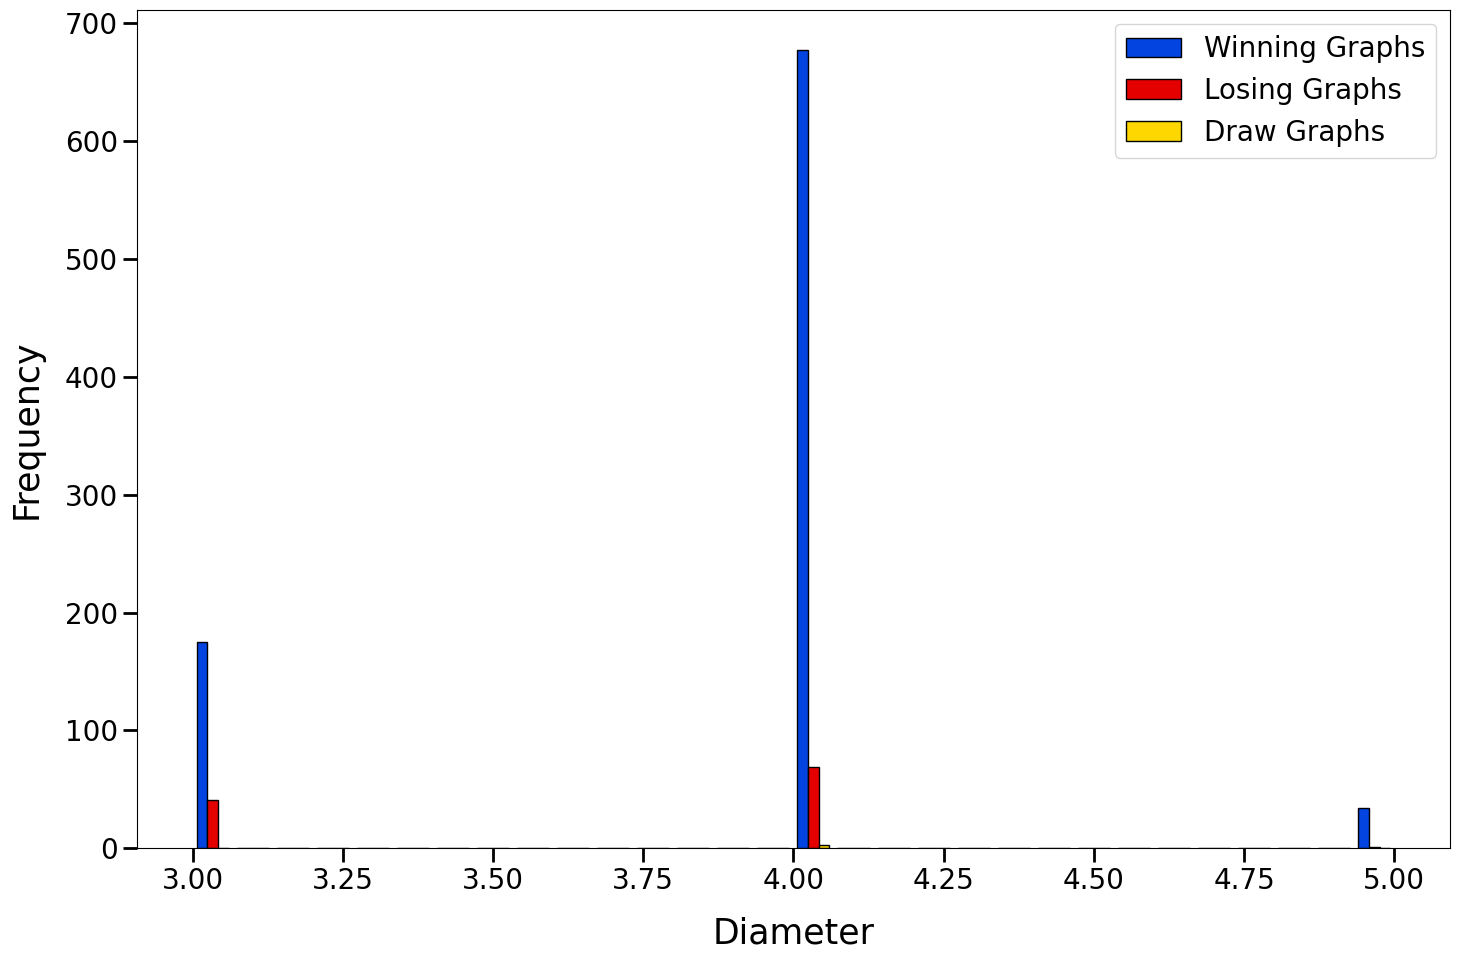

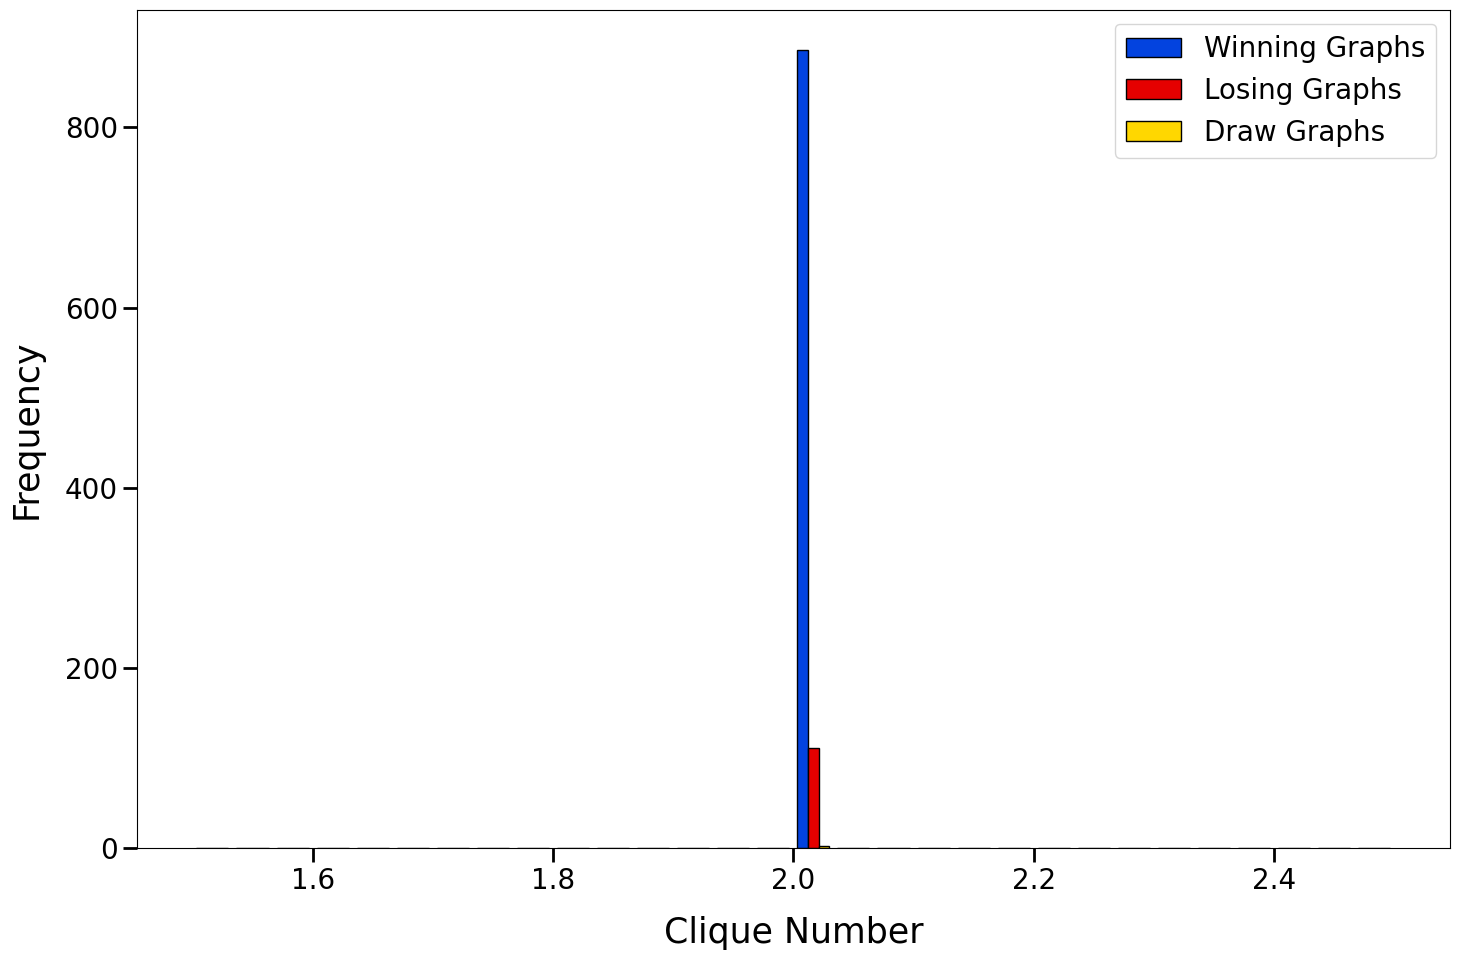

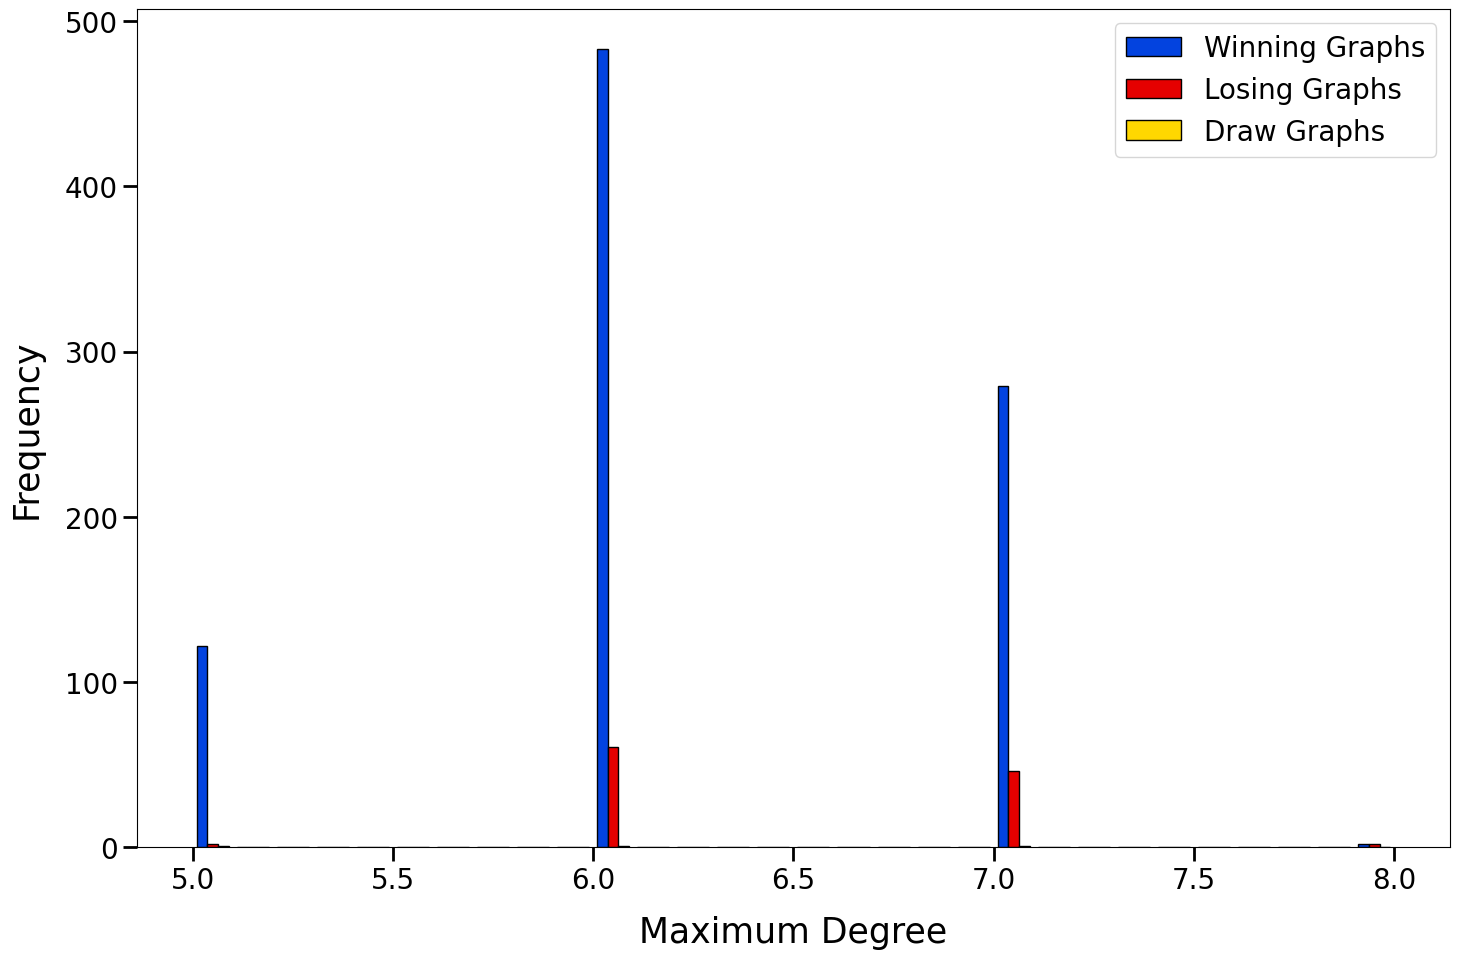

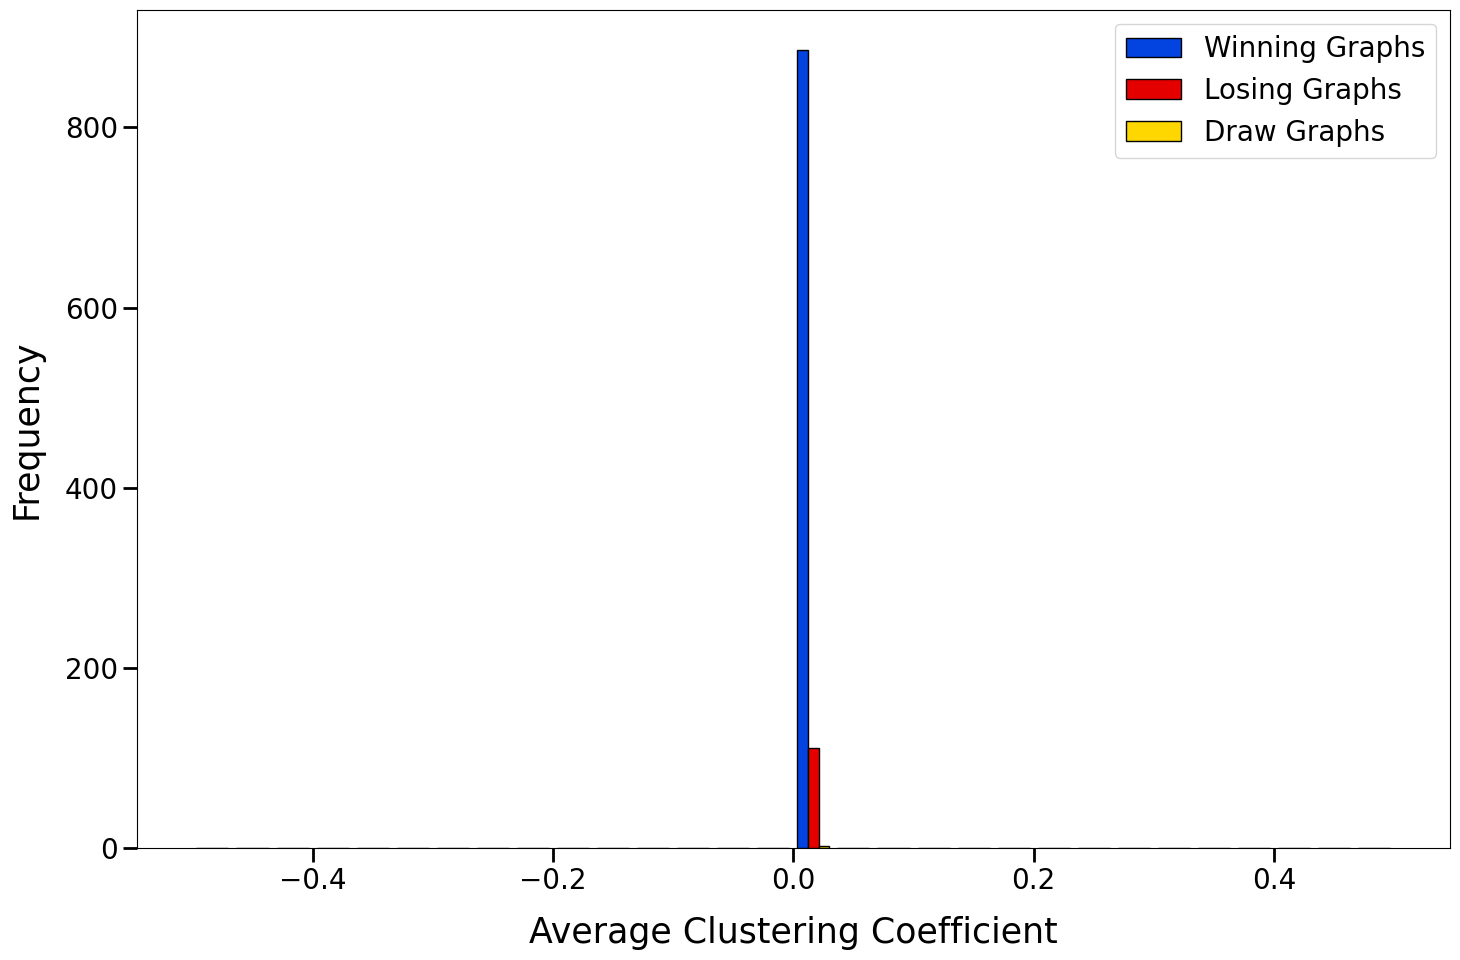

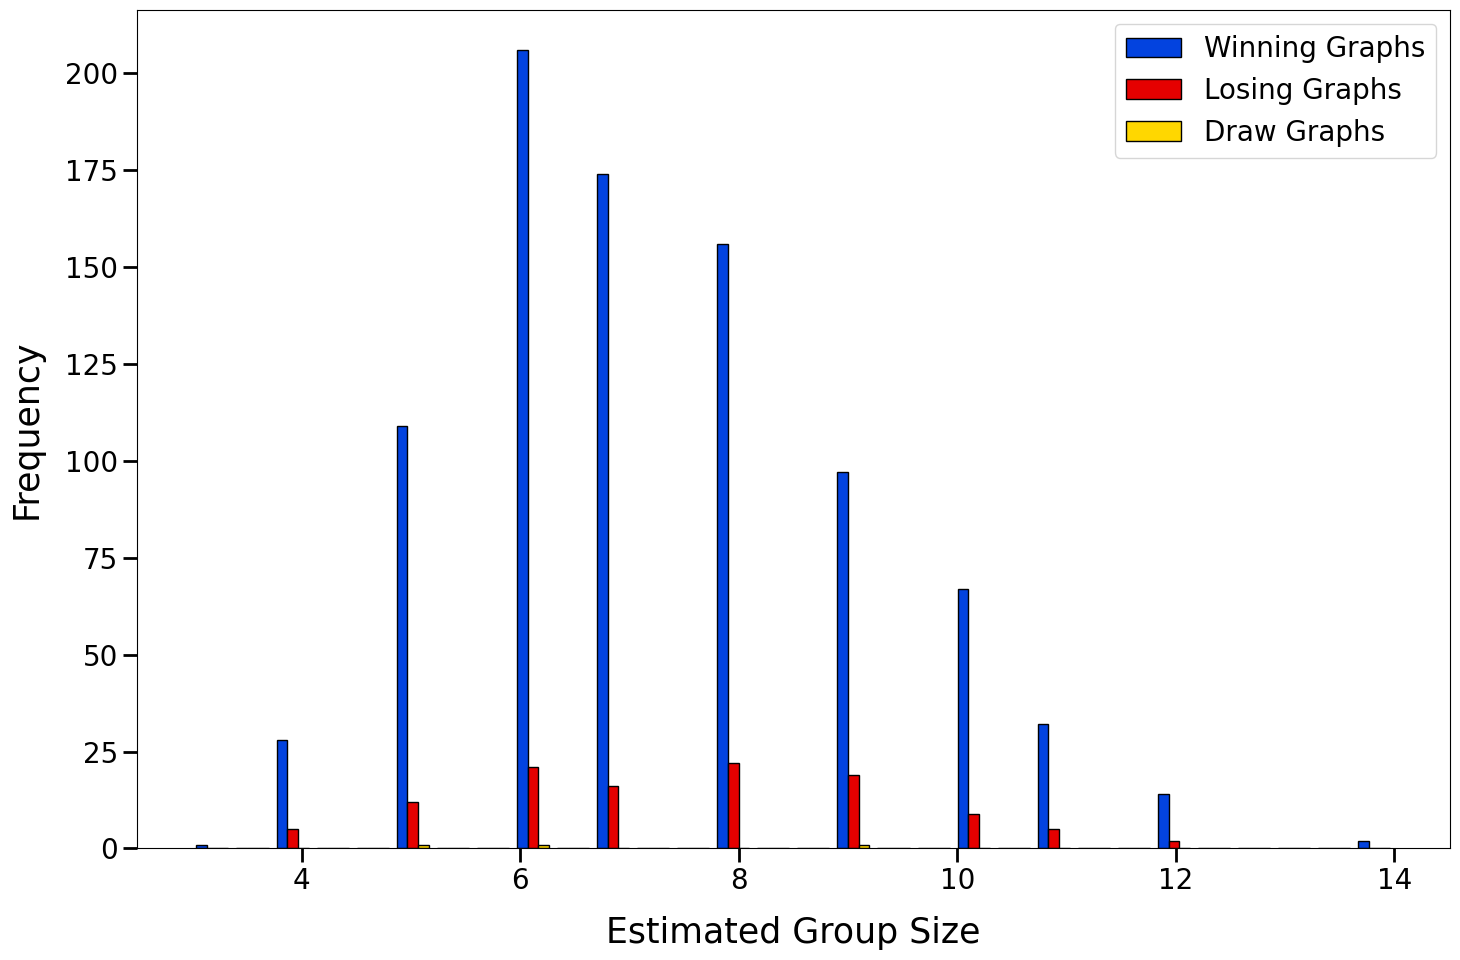

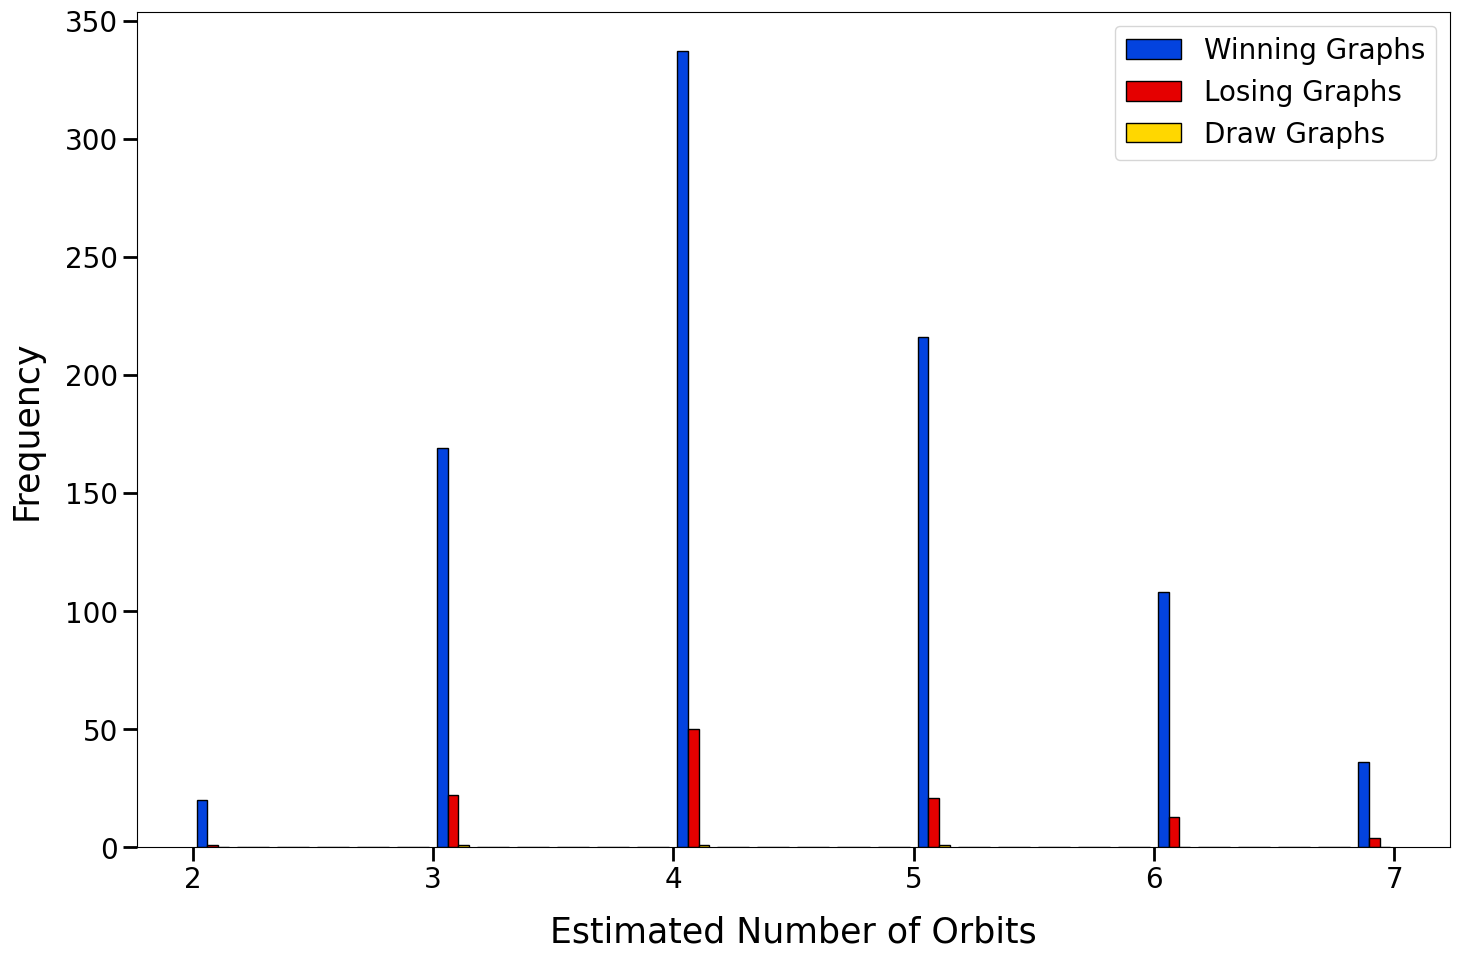

In [3]:
# Define colors for three categories
WINNING_COLOR = '#0343df'  # blue
LOSING_COLOR = '#e50000'   # red
DRAW_COLOR = '#ffd700'     # yellow

# Set plot parameters
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

# Collect properties for all three categories
n_vertices = 2**4

winning_props = collect_graph_properties(f'../data/graphs/negative_{n_vertices}cgraphs.g6', n_vertices)
losing_props = collect_graph_properties(f'../data/graphs/positive_{n_vertices}cgraphs.g6', n_vertices)
draw_props = collect_graph_properties(f'../data/graphs/zero_{n_vertices}cgraphs.g6', n_vertices)

plots_folder = '../data/plots/'

def plot_comparison_histogram(win_data, lose_data, draw_data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    all_data = np.concatenate([win_data, lose_data, draw_data])
    bins = np.histogram(all_data, bins=30)[1]  # Get the bin edges
    
    plt.hist([win_data, lose_data, draw_data], bins=bins, 
             label=['Winning Graphs', 'Losing Graphs', 'Draw Graphs'],
             color=[WINNING_COLOR, LOSING_COLOR, DRAW_COLOR], 
             histtype='bar', edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.legend(prop={'size': 20})
    plt.tick_params(axis='both', which='major', labelsize=20, length=10, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=15, length=5, width=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def plot_comparison_bar(win_data, lose_data, draw_data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    x = np.arange(2)
    width = 0.25  # Reduced width to fit three bars
    
    plt.bar(x - width, [win_data[False], win_data[True]], width, 
           label='Winning Graphs', color=WINNING_COLOR, edgecolor='black')
    plt.bar(x, [lose_data[False], lose_data[True]], width, 
           label='Losing Graphs', color=LOSING_COLOR, edgecolor='black')
    plt.bar(x + width, [draw_data[False], draw_data[True]], width, 
           label='Draw Graphs', color=DRAW_COLOR, edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.xticks(x, ['Non-bipartite', 'Bipartite'], rotation=0)
    plt.legend(prop={'size': 20})
    plt.tick_params(axis='both', which='major', labelsize=20, length=10, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=15, length=5, width=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Generate all comparison plots
plot_comparison_histogram(
    winning_props['edge_counts'], 
    losing_props['edge_counts'],
    draw_props['edge_counts'],
    '', 'Edge Count', 'Frequency', 
    plots_folder+f'edge_counts_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['edge_densities'], 
    losing_props['edge_densities'],
    draw_props['edge_densities'],
    '', 'Edge Density', 'Frequency', 
    plots_folder+f'edge_density_comparison_{n_vertices}c.pdf'
)

plot_comparison_bar(
    winning_props['bipartite_counts'],
    losing_props['bipartite_counts'],
    draw_props['bipartite_counts'],
    '', '', 'Count',
    plots_folder+f'bipartiteness_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['diameters'],
    losing_props['diameters'],
    draw_props['diameters'],
    '', 'Diameter', 'Frequency',
    plots_folder+f'diameters_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['clique_numbers'],
    losing_props['clique_numbers'],
    draw_props['clique_numbers'],
    '', 'Clique Number', 'Frequency',
    plots_folder+f'clique_numbers_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['max_degrees'],
    losing_props['max_degrees'],
    draw_props['max_degrees'],
    '', 'Maximum Degree', 'Frequency',
    plots_folder+f'max_degrees_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['clustering_coefficients'],
    losing_props['clustering_coefficients'],
    draw_props['clustering_coefficients'],
    '', 'Average Clustering Coefficient', 'Frequency',
    plots_folder+f'clustering_coefficients_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['group_sizes'],
    losing_props['group_sizes'],
    draw_props['group_sizes'],
    '', 'Estimated Group Size', 'Frequency',
    plots_folder+f'group_sizes_comparison_{n_vertices}c.pdf'
)

plot_comparison_histogram(
    winning_props['orbit_counts'],
    losing_props['orbit_counts'],
    draw_props['orbit_counts'],
    '', 'Estimated Number of Orbits', 'Frequency',
    plots_folder+f'orbit_counts_comparison_{n_vertices}c.pdf'
)

In [4]:
# Print statistics for all three groups
for group_name, props in [("Winning", winning_props), 
                         ("Losing", losing_props), 
                         ("Draw", draw_props)]:
    
    try: 
        print(f"\n{group_name} Graphs Statistics:")
        print(f"Total graphs processed: {len(props['edge_counts'])}")
        print(f"Edge count - Min: {min(props['edge_counts'])}, Max: {max(props['edge_counts'])}, Mean: {np.mean(props['edge_counts']):.2f}")
        print(f"Edge density - Min: {min(props['edge_densities']):.4f}, Max: {max(props['edge_densities']):.4f}, Mean: {np.mean(props['edge_densities']):.4f}")
        print(f"Bipartite graphs: {props['bipartite_counts'][True]}, Non-bipartite graphs: {props['bipartite_counts'][False]}")
        print(f"Diameter - Min: {min(props['diameters'])}, Max: {max(props['diameters'])}, Mean: {np.mean(props['diameters']):.2f}")
        print(f"Clique number - Min: {min(props['clique_numbers'])}, Max: {max(props['clique_numbers'])}, Mean: {np.mean(props['clique_numbers']):.2f}")
        print(f"Maximum degree - Min: {min(props['max_degrees'])}, Max: {max(props['max_degrees'])}, Mean: {np.mean(props['max_degrees']):.2f}")
        print(f"Clustering coefficient - Min: {min(props['clustering_coefficients'])}, Max: {max(props['clustering_coefficients'])}, Mean: {np.mean(props['clustering_coefficients']):.2f}")
        print(f"Estimated group size - Min: {min(props['group_sizes'])}, Max: {max(props['group_sizes'])}, Mean: {np.mean(props['group_sizes']):.2f}")
        print(f"Estimated orbit count - Min: {min(props['orbit_counts'])}, Max: {max(props['orbit_counts'])}, Mean: {np.mean(props['orbit_counts']):.2f}")
    except: continue


Winning Graphs Statistics:
Total graphs processed: 886
Edge count - Min: 29, Max: 44, Mean: 33.42
Edge density - Min: 0.2417, Max: 0.3667, Mean: 0.2785
Bipartite graphs: 886, Non-bipartite graphs: 0
Diameter - Min: 3, Max: 5, Mean: 3.84
Clique number - Min: 2, Max: 2, Mean: 2.00
Maximum degree - Min: 5, Max: 8, Mean: 6.18
Clustering coefficient - Min: 0.0, Max: 0.0, Mean: 0.00
Estimated group size - Min: 3, Max: 14, Mean: 7.28
Estimated orbit count - Min: 2, Max: 7, Mean: 4.37

Losing Graphs Statistics:
Total graphs processed: 111
Edge count - Min: 30, Max: 46, Mean: 35.32
Edge density - Min: 0.2500, Max: 0.3833, Mean: 0.2943
Bipartite graphs: 111, Non-bipartite graphs: 0
Diameter - Min: 3, Max: 5, Mean: 3.64
Clique number - Min: 2, Max: 2, Mean: 2.00
Maximum degree - Min: 5, Max: 8, Mean: 6.43
Clustering coefficient - Min: 0.0, Max: 0.0, Mean: 0.00
Estimated group size - Min: 4, Max: 12, Mean: 7.51
Estimated orbit count - Min: 2, Max: 7, Mean: 4.32

Draw Graphs Statistics:
Total grap